In [1]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from glob import glob 
import random

In [2]:
files= [("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_1/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_1/topol.xtc"),
        ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_2/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_2/topol.xtc"),
        ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_3/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_3/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_4/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_4/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_5/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_5/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_6/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_6/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_7/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_7/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_8/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_8/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_9/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_9/topol.xtc"),
       ("/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_10/topol.tpr"
         ,"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_10/topol.xtc"),]

Calculate COM based on MDAnalysis (this can also be done via PLUMED, but it didn't work for me during this stage).It is also recommended to only use the phosphor groups of the membrane bilayer as less atoms are taken into account to calculate the center of the membrane among the z-distance.

In [3]:
def get_com(u, sel: str, sel2: str):
    com_arr = np.empty((u.trajectory.n_frames, 3))
    select_group1 = u.select_atoms(sel)
    select_group2 = u.select_atoms(sel2)
    for frame in u.trajectory:
        if not frame.frame %1:
            print(frame.frame)
        com_arr[frame.frame, :] = select_group1.center_of_mass(unwrap=True)-select_group2.center_of_mass() # remove PBCs
    return com_arr

In [4]:
BDQ_com_all_reps = np.empty((10, 101, 3))

for i, simulation in enumerate(files):
    topology, trajectory = simulation
    u = mda.Universe(topology, trajectory)
    print(u.trajectory)
    BDQ_com_all_reps[i, :, :] = get_com(u, sel = "resname BDQ and not name H*", sel2="name P")

<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_1/topol.xtc with 101 frames of 43975 atoms>
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_2/topol.xtc with 101 frames of 43975 atoms>
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
<XTCReader /scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/memb_bdq2/Equil/TPS/production_replicates/rep_3/topol.x

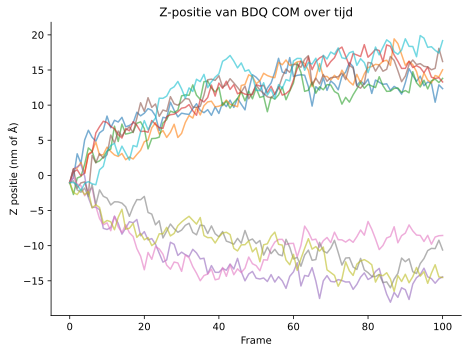

In [10]:
import matplotlib.pyplot as plt
import numpy as np

for i in range(BDQ_com_all_reps.shape[0]):
    plt.plot(BDQ_com_all_reps[i, :, 2], alpha=0.6)

plt.xlabel("Frame")
plt.ylabel("Z positie (nm of Å)")
plt.title("Z-positie van BDQ COM over tijd")
plt.show()

[[[-2.42387756e+00  1.95422528e+00 -9.56022366e-01]
  [-1.78864749e+00 -3.21921217e-02 -3.21292059e-01]
  [-2.80849084e+00  2.01423606e-01  3.09887795e+00]
  ...
  [-1.44015624e+01  6.29418823e+00  1.04550662e+01]
  [-1.65809767e+01  5.55661842e+00  1.28595284e+01]
  [-1.67940300e+01  5.43725320e+00  1.24310850e+01]]

 [[-2.42387756e+00  1.95422528e+00 -9.56022366e-01]
  [-9.01618177e-01  1.26035501e+00  9.65965294e-01]
  [-1.53553835e+00 -4.12286778e-01  1.05343725e+00]
  ...
  [-2.02910389e+00  4.57375175e+00  1.41095341e+01]
  [-2.95413323e+00  5.26939469e+00  1.39585335e+01]
  [-2.81359651e+00  4.94040795e+00  1.49581850e+01]]

 [[-2.42387756e+00  1.95422528e+00 -9.56022366e-01]
  [-2.68961418e+00 -1.23329214e+00 -2.77214707e+00]
  [-1.81418818e+00  9.66513060e-01 -4.17658309e-01]
  ...
  [-3.51460853e+00 -8.15480826e+00  1.37848985e+01]
  [-4.46971713e+00 -8.94767768e+00  1.32968263e+01]
  [-5.27678716e+00 -8.93448146e+00  1.38260248e+01]]

 ...

 [[-2.42387756e+00  1.95422528e+00

This code underneath searches for possible frames among all the trajectories you gave as input and searches for every match on which the value of the CV is nearer a chosen value (here, spacing between different CV values was 1 angtröm and spacing was 0.125 angström.) It also chooses at random one frame. This will be used as input for umbrella sampling. 

In [5]:
def get_close_idx_com(BDQ_com_all_reps, target_z, tolerance):

    z_values = BDQ_com_all_reps[:,:,2]
    close_idx = np.argwhere(np.isclose(z_values, target_z, atol=tolerance))
    
    n_matches = len(close_idx)
    
    if n_matches == 0:
        return None, None, 0
    
    random_idx = np.random.randint(0, n_matches)
    choice = close_idx[random_idx]
    
    value = z_values[choice[0], choice[1]]
    
    return value, choice, n_matches

This writes the desired frame in gro format.

In [6]:
def write_frame_mda(topology_file, trajectory_file, frame_index, output_file):
    import MDAnalysis as mda
    
    u = mda.Universe(topology_file, trajectory_file)
    ag = u.select_atoms("all")
    
    u.trajectory[frame_index]  # spring naar het gewenste frame
    with mda.Writer(output_file, ag.n_atoms) as w:
        w.write(ag)

In [7]:
phosphate = u.select_atoms("name P")
plumed_idx = phosphate.indices + 1
atomlist = ",".join(map(str, plumed_idx))

This code constructs the plumed file. It didn't work for me yet.

In [10]:
def write_plumed(filename: str, where: int):
    colvar_outname = os.path.basename(filename).rstrip('.dat')
    with open(filename, 'w') as outfile:
        outfile.write("UNITS LENGTH=A \n") # values in angstrom
        outfile.write("WHOLEMOLECULES ENTITY0=1-69 \n")
        outfile.write(f"MOLINFO STRUCTURE={colvar_outname}.pdb  \n") # Reference file; important! You should select the frame that was chosen (CV value across this snap should match)
        outfile.write("bdq: COM ATOMS=1-37 \n") # exclude H-atoms of the ligand
        outfile.write(f"pop: COM ATOMS=70-24069\n") # membrane bilayer
        outfile.write("d1: DISTANCE ATOMS=pop,bdq COMPONENTS \n") # According to chatgpt, the CV is calculated as follows COM(ligand) - COM(phosphor groups). I think that the order on which you give the atoms is here important.
        umbrella = f"z: RESTRAINT ARG=d1.z KAPPA=15.0 AT={where}" # kappa = strength of the bias that should be introduced (in  kJmol^−1˚ A^−2 ); where= chosen CV value. Frame was chosen via get_close_idx_com. 
        outfile.write(umbrella)
        outfile.write("\n")
        f = f"PRINT ARG=d1.z FILE={colvar_outname}-colvar_5.dat STRIDE=1" # prints the CV value over time
        outfile.write(f)
        outfile.write("\n")
    return  # You may return something meaningful here if needed

In [10]:
target_z_values = np.arange(-16, 19, 1)
tolerance = 0.125

for i, z_target in enumerate(target_z_values):
    
    value, idx, n_matches = get_close_idx_com(BDQ_com_all_reps, z_target, tolerance)

    if idx is None:
        print(f"Skipping target {z_target} (0 matches)")
        continue

    rep, frame = idx

    print(f"Target: {z_target}, Matches: {n_matches}, Selected value: {value}, Rep: {rep}, Frame: {frame}")
    
    topology_file, trajectory_file = files[rep]
    
    output_file = f"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/umbrella/configurations/frame_z{i+1}.gro"
    plumedfile= f"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/umbrella/plumed/plumed_{i+1}.dat"
    
    write_frame_mda(topology_file, trajectory_file, frame, output_file)
    write_plumed(plumedfile, value)
    

Target: -16, Matches: 3, Selected value: -15.990080637051612, Rep: 7, Frame: 86
Target: -15, Matches: 9, Selected value: -15.007184565406089, Rep: 4, Frame: 68
Target: -14, Matches: 11, Selected value: -14.086727542900405, Rep: 7, Frame: 83
Target: -13, Matches: 5, Selected value: -13.027345989487198, Rep: 7, Frame: 76
Target: -12, Matches: 10, Selected value: -11.877961674880023, Rep: 4, Frame: 35
Target: -11, Matches: 7, Selected value: -11.034038219685169, Rep: 4, Frame: 34
Target: -10, Matches: 5, Selected value: -9.987288481392856, Rep: 8, Frame: 22
Target: -9, Matches: 12, Selected value: -9.094108913924682, Rep: 7, Frame: 58
Target: -8, Matches: 10, Selected value: -7.895630919457933, Rep: 6, Frame: 92
Target: -7, Matches: 8, Selected value: -7.0304161041506035, Rep: 7, Frame: 23
Target: -6, Matches: 2, Selected value: -5.959453552096566, Rep: 8, Frame: 13
Target: -5, Matches: 1, Selected value: -4.87871025444349, Rep: 4, Frame: 8
Target: -4, Matches: 1, Selected value: -3.94265


KeyboardInterrupt


KeyboardInterrupt



array([[[ -2.05343097,   3.13974301,  -0.98961225],
        [ -1.27253513,   1.7002544 ,  -0.28680415],
        [ -2.69277817,   0.95103284,   3.14750115],
        ...,
        [-14.66805887,   6.23539844,  10.48359857],
        [-17.08148581,   5.68761739,  12.92190709],
        [-16.80637879,   5.621866  ,  12.38363542]],

       [[ -2.05343097,   3.13974301,  -0.98961225],
        [ -0.80469946,   0.84723183,   1.03132779],
        [ -1.59029628,   0.46505525,   1.13283734],
        ...,
        [ -2.54087117,   3.36729072,  14.32117058],
        [ -1.84679047,   4.3219694 ,  14.06500969],
        [ -2.85189126,   3.5685222 ,  15.10243539]],

       [[ -2.05343097,   3.13974301,  -0.98961225],
        [ -1.95522577,   0.24014472,  -2.67661187],
        [ -1.066132  ,   2.44795531,  -0.31135566],
        ...,
        [ -3.31603828,  -8.25806668,  13.75146231],
        [ -5.11026544,  -8.64460415,  13.27159927],
        [ -5.82613684,  -8.4211512 ,  13.85120746]],

       ...,

      

-18.019141071471584 19.915714778180266


In [11]:
target_z_values = np.arange(-10.5, 10.5, 1)
tolerance = 0.125

for i, z_target in enumerate(target_z_values):
    
    value, idx, n_matches = get_close_idx_com(BDQ_com_all_reps, z_target, tolerance)

    if idx is None:
        print(f"Skipping target {z_target} (0 matches)")
        continue

    rep, frame = idx

    print(f"Target: {z_target}, Matches: {n_matches}, Selected value: {value}, Rep: {rep}, Frame: {frame}")
    
    topology_file, trajectory_file = files[rep]
    
    output_file = f"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/umbrella/configurations/frame_z{i+69}.gro"
    plumedfile= f"/scratch/gent/vo/000/gvo00003/vsc48847/mem_bdq2/umbrella/plumed/plumed_{i+69}.dat"
    
    write_frame_mda(topology_file, trajectory_file, frame, output_file)
    write_plumed(plumedfile, value)

Target: -10.5, Matches: 12, Selected value: -10.517690482638258, Rep: 7, Frame: 55
ERROR! Session/line number was not unique in database. History logging moved to new session 1627
Target: -9.5, Matches: 11, Selected value: -9.402091039684496, Rep: 6, Frame: 95
Target: -8.5, Matches: 12, Selected value: -8.611904407842577, Rep: 8, Frame: 27
Target: -7.5, Matches: 6, Selected value: -7.499541919737219, Rep: 4, Frame: 15
Target: -6.5, Matches: 6, Selected value: -6.386130733810845, Rep: 8, Frame: 33
Target: -5.5, Matches: 1, Selected value: -5.507974574685257, Rep: 7, Frame: 22
Target: -4.5, Matches: 6, Selected value: -4.564663254605648, Rep: 8, Frame: 8
Target: -3.5, Matches: 2, Selected value: -3.44324921049337, Rep: 7, Frame: 18
Target: -2.5, Matches: 2, Selected value: -2.3978888785770067, Rep: 7, Frame: 3
Target: -1.5, Matches: 1, Selected value: -1.4528461556382695, Rep: 6, Frame: 3
Skipping target -0.5 (0 matches)
Target: 0.5, Matches: 1, Selected value: 0.5047668846014446, Rep: 3